## Import modules

In [1]:
%reload_ext autoreload
%autoreload 2

from interpolation_uncertainty.core.loadfile import load_file
from interpolation_uncertainty.processors.rasterProcessor import RasterProcessor
from interpolation_uncertainty.utils import utils
import numpy as np


## Load Bathymetry Dataset

In [2]:
# define bathymetry filename and load
filename = "data/raster/BlueTopo.tiff"
bathy_data = load_file(filename)
bathy_data

RasterDataset(data=BathymetryDataset(data=RasterDataset([[-43.517, -42.848, -42.954, ..., -90.035, -90.044,
                -90.057],
               [-41.423, -40.985, -42.603, ..., -90.041, -90.044,
                -90.052],
               [-40.001, -39.78 , -40.276, ..., -90.024, -90.035,
                -90.047],
               ...,
               [-58.567, -58.605, -58.676, ..., -99.965, -99.969,
                -99.973],
               [-58.617, -58.69 , -58.731, ..., -99.973, -99.99 ,
                -99.99 ],
               [-58.66 , -58.732, -58.817, ..., -99.971, -99.977,
                -99.984]], shape=(2035, 1493), dtype=float32), 
filename='BlueTopo.tiff', 
filetype='raster, 
metadata='{'ndv_value': 1000000.0, 'resolution': 4.0, 'full_path': 'data\\raster\\BlueTopo.tiff'}'), 
shape: (2035, 1493),
filename='BlueTopo.tiff', 
full path: data\raster\BlueTopo.tiff,
resolution: 4.0,
ndv_value: 1000000.0,
filetype='raster, 
metadata='{'ndv_value': 1000000.0, 'resolution': 4.0, 'f

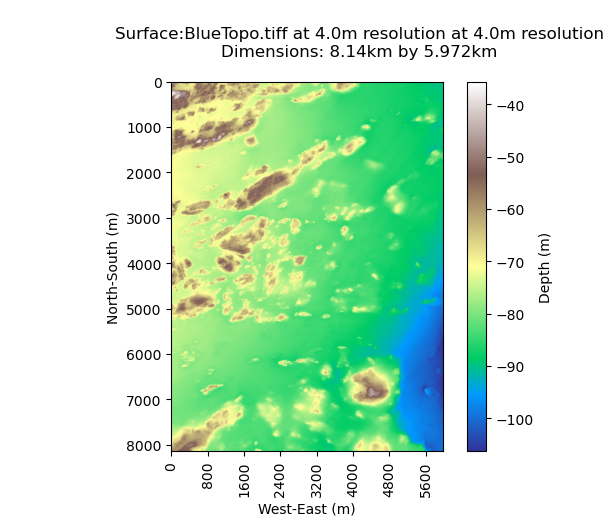

In [3]:
# Optionally, plot the loaded raster bathymetry file
bathy_data.show_depth()

## Define Subsampling Parameters

Subsample full coverage dataset (geoTiffs) into simulated surveys

In [4]:
# define processing parameters
linespacing = 256
max_multiple = 1
current_multiple = 1
processor = RasterProcessor(linespacing_meters=linespacing,
                            max_multiple=max_multiple,
                            multiple=current_multiple)

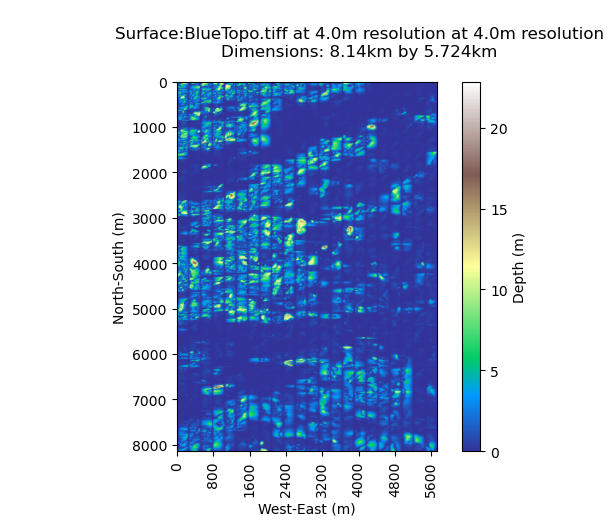

In [5]:
residual = processor.compute_residual_surface(bathy_data)
residual.show_depth()

In [6]:
uncertainty_amp_v1 = processor.estimate_uncertainty(method='amp_v1', residual_data=residual)
uncertainty_psd_v1 = processor.estimate_uncertainty(method='psd_v1', residual_data=residual)
uncertainty_amp_elias = processor.estimate_uncertainty(method='amp_v2', residual_data=residual)
uncertainty_psd_n = processor.estimate_uncertainty(method='psd_n', residual_data=residual)
uncertainty_psd_lf = processor.estimate_uncertainty(method='psd_lf', residual_data=residual)
uncertainty_psd_df = processor.estimate_uncertainty(method='psd_df', residual_data=residual)
uncertainty_spectrum_elias = processor.estimate_uncertainty(method='spectrum', residual_data=residual)
uncertainty_spatial_std = processor.estimate_uncertainty(method='spatial_std', residual_data=residual)
uncertainty_spatial_diff = processor.estimate_uncertainty(method='spatial_diff', residual_data=residual)
uncertainty_spatial_gaussian = processor.estimate_uncertainty(method='spatial_gaussian', residual_data=residual)


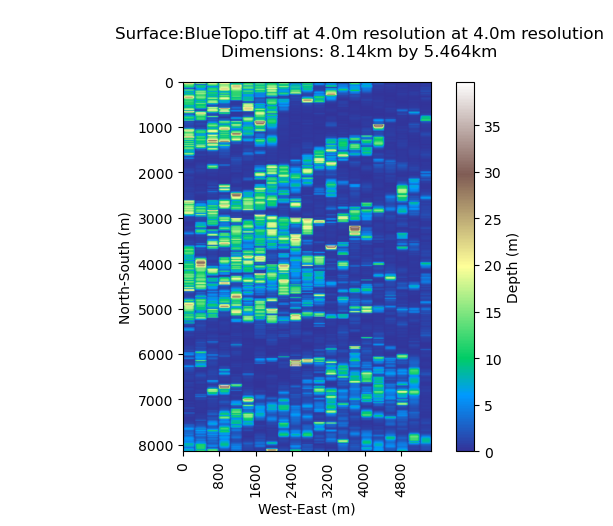

In [7]:
uncertainty_amp_v1.show_depth()

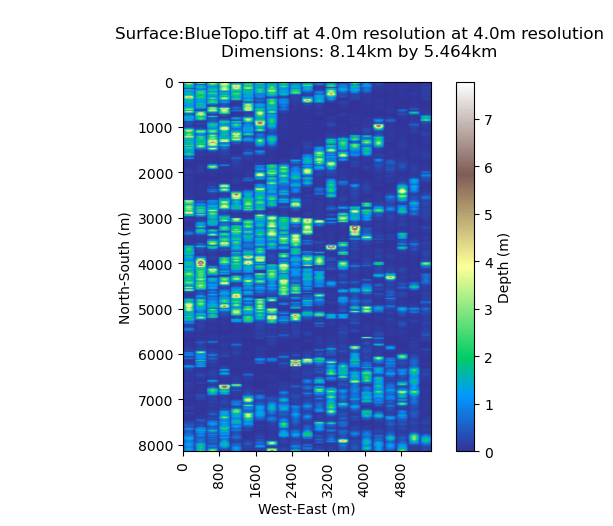

In [8]:
spatial_std_env1 = uncertainty_spatial_std['std_envelope1']
spatial_std_env1.show_depth()



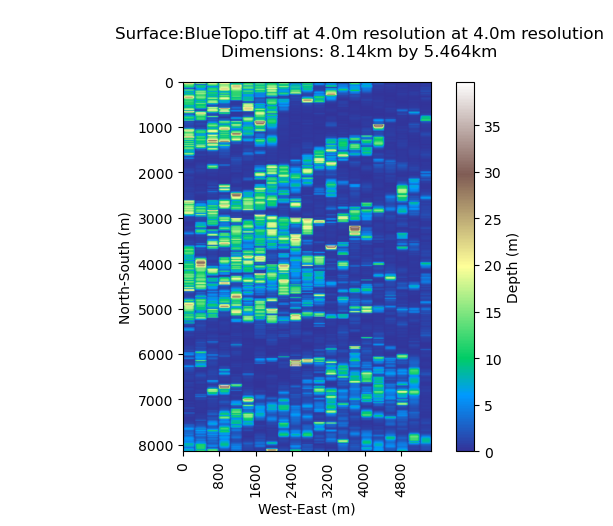

In [9]:
uncertainty_amp_v1.show_depth()

In [10]:
# extract new number of cols from uncertainty estimates, choose any
num_cols = uncertainty_psd_n.shape[1]

# crop residual data to match number of cols of uncertainty estimates
residual_data = residual[:, :num_cols]

# create dict of uncertainty_estimates for comparison
uncertainties_dict = {
    "Amplitude": uncertainty_amp_v1,
    "PSD(F)": uncertainty_psd_v1,
    "Amplitude (Elias)": uncertainty_amp_elias,
    "ASD": uncertainty_amp_elias,
    "PSD(n)": uncertainty_psd_n,
    "PSD(lf)": uncertainty_psd_lf,
    "PSD(df)": uncertainty_psd_df,
    "Spatial Max Diff": uncertainty_spatial_diff['difference_max'],
    "Spatial Diff Envelope1": uncertainty_spatial_diff['difference_envelope1'],
    "Spatial Gaussian 95%": uncertainty_spatial_gaussian['gaussian_p95'],
    "Spatial Gaussian 99%": uncertainty_spatial_gaussian['gaussian_p99'],
    "Spatial Gaussian Mean": uncertainty_spatial_gaussian['gaussian_mean'],
    }



(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034, 2034], shape=(2734910,)), array([   1,    2,    3, ..., 1362, 1363, 1364], shape=(2734910,)))
(array([   0,    0,    0, ..., 2034, 2034

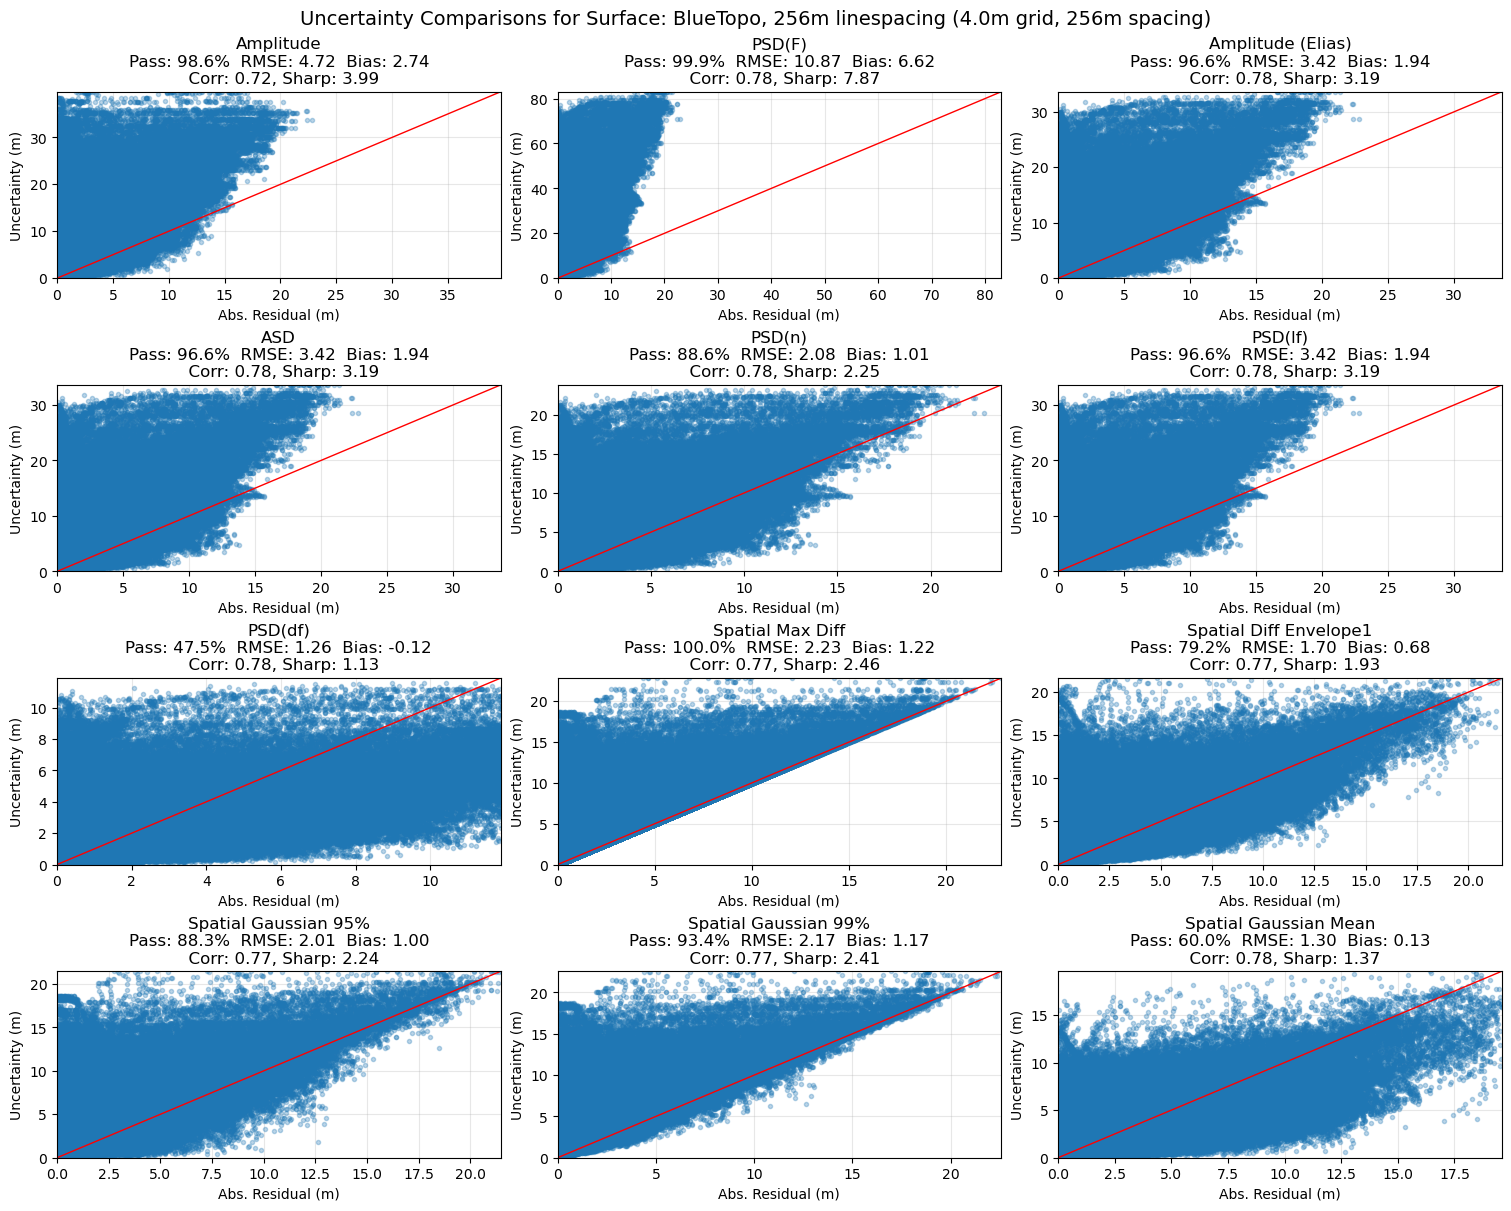

In [11]:
utils.multi_uncertainty_comparison(
    residuals=residual_data,
    uncertainties_dict=uncertainties_dict,
    resolution=bathy_data.metadata['resolution'],
    desired_linespacing_meters=linespacing,
    fn=f"Surface: BlueTopo, {linespacing}m linespacing",
    plot_grid=(4, 3),
    # path="./",
    # plot_boxplots=True
);